# Analisis prediksi XGBoost — `concat.csv`

**Target regresi:** drift translasi dalam **jarak skalar** (norma Euclidean $\sqrt{dx^2+dy^2+dz^2}$), bukan prediksi per komponen sumbu.  
**Fitur yang dihapus dari X:** timestamp (`timestamp`, `realtime_sec`, `track_inner_ms`), ordinal (`frame`, `tracking_state_2`, `tracking_state_3`), komponen translasi (`dx`, `dy`, `dz`) dan `e_trans` (menghindari leakage ke target jarak), serta rotasi (`drx`, `dry`, `drz`).  
**Reproducibility:** seed tetap untuk NumPy, PyTorch, scikit-learn, XGBoost, dan Optuna.

Notebook ini mencakup preprocessing, baseline XGBoost, tuning hyperparameter, optimasi tambahan, interpretasi importance & SHAP, serta model LSTM dan PatchTST dengan latent **sama** dengan jumlah fitur (tanpa kompresi), lalu XGBoost.

**Urutan temporal:** `__row_order__` (indeks baris asli CSV); model sekuensial memakai jendela geser (`SEQ_LEN`).

In [1]:
%pip install -q pandas numpy scipy matplotlib seaborn scikit-learn xgboost optuna shap torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV,
    learning_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression, RFE, SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import VotingRegressor
from IPython.display import display

import xgboost as xgb
from xgboost import callback as xgb_callback
import optuna
from optuna.samplers import RandomSampler, TPESampler
import shap
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------- Config --------------------
DATA_PATH = Path("concat.csv")
# Target = drift translasi sebagai jarak skalar (bukan dimensional per sumbu)
TARGET_COL = "__drift_distance__"
DROP_FROM_FEATURES = [
    "timestamp",
    "realtime_sec",
    "track_inner_ms",
    "frame",
    "drx",
    "dry",
    "drz",
    "dx",
    "dy",
    "dz",
    "e_trans",
    "tracking_state_2",
    "tracking_state_3",
]
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_JOBS = -1
SEQ_LEN = 32  # panjang jendela untuk LSTM / PatchTST
PATCH_LEN = 8
PATCH_STRIDE = 4

def set_seeds(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()

def metrics_dict(y_true, y_pred, prefix: str) -> dict:
    return {
        f"{prefix}_r2": r2_score(y_true, y_pred),
        f"{prefix}_rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        f"{prefix}_mae": mean_absolute_error(y_true, y_pred),
    }

def print_metrics(title: str, d: dict) -> None:
    print(title)
    for k in sorted(d):
        print(f"  {k}: {d[k]:.6f}")

sns.set_theme(style="whitegrid", context="notebook")
print("Device PyTorch:", "cuda" if torch.cuda.is_available() else "cpu")

Device PyTorch: cpu


## 1. Preprocessing data

In [3]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df_raw["__row_order__"] = np.arange(len(df_raw), dtype=np.int64)

print("Shape:", df_raw.shape)
print("Duplikat baris (full-row):", int(df_raw.duplicated().sum()))

need_xyz = {"dx", "dy", "dz"}
if not need_xyz.issubset(df_raw.columns):
    raise ValueError("Kolom dx, dy, dz diperlukan untuk menghitung drift jarak (target).")

# Target: drift translasi sebagai jarak (norma Euclidean)
df_raw[TARGET_COL] = np.sqrt(
    df_raw["dx"].astype(float) ** 2
    + df_raw["dy"].astype(float) ** 2
    + df_raw["dz"].astype(float) ** 2
)

# Missing values
na_counts = df_raw.isna().sum()
na_cols = na_counts[na_counts > 0]
print("Kolom dengan NA:", len(na_cols))
if len(na_cols):
    display(na_cols.sort_values(ascending=False).head(20))

# Outlier ringkas (IQR per kolom numerik)
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
outlier_frac = {}
for c in num_cols:
    s = df_raw[c].dropna()
    if s.empty:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_frac[c] = float(((s < lo) | (s > hi)).mean())

outlier_frac = pd.Series(outlier_frac).sort_values(ascending=False)
print("Top 10 kolom dengan fraksi outlier IQR tertinggi:")
display(outlier_frac.head(10))

present_drop = [c for c in DROP_FROM_FEATURES if c in df_raw.columns]
feat_block = df_raw.drop(columns=[TARGET_COL] + present_drop, errors="ignore")
X_df = feat_block.select_dtypes(include=[np.number]).copy()
if "__row_order__" in X_df.columns:
    X_df = X_df.drop(columns=["__row_order__"])

y = df_raw[TARGET_COL].astype(float).values
feature_names = X_df.columns.tolist()
print("Jumlah fitur numerik:", len(feature_names))
print("Target (drift jarak) mean:", float(np.nanmean(y)), "std:", float(np.nanstd(y)))

if X_df.isna().any().any():
    X_df = X_df.fillna(X_df.median(numeric_only=True))

X = X_df.values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, "| Test:", X_test_s.shape)

Shape: (23994, 65)
Duplikat baris (full-row): 0
Kolom dengan NA: 0
Top 10 kolom dengan fraksi outlier IQR tertinggi:


dry                       0.235225
velocity_acceleration     0.194924
velocity_change           0.193673
velocity_change_lag1      0.193673
keypoints_rolling_mean    0.176252
keypoints                 0.154830
tracking_health_score     0.154205
drx                       0.147870
map_inliers_trend         0.143453
feature_spread_trend      0.128574
dtype: float64

Jumlah fitur numerik: 51
Target (drift jarak) mean: 0.047060887520111803 std: 0.20353724194360254
Train: (19195, 51) | Test: (4799, 51)


## 2. Baseline XGBoost Regressor

Baseline XGBoost
  test_mae: 0.011438
  test_r2: 0.576003
  test_rmse: 0.118041
  train_mae: 0.003158
  train_r2: 0.998502
  train_rmse: 0.008078


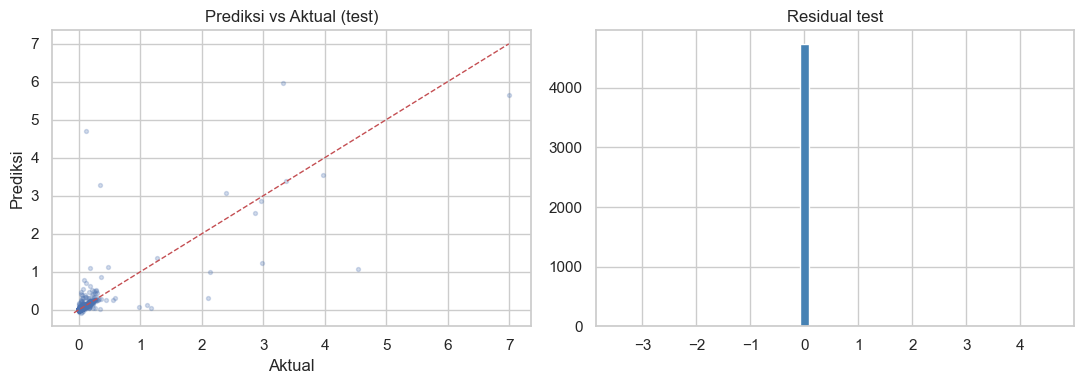

In [4]:
baseline = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    tree_method="hist",
)
baseline.fit(X_train_s, y_train)
pred_tr = baseline.predict(X_train_s)
pred_te = baseline.predict(X_test_s)

m_base = {}
m_base.update(metrics_dict(y_train, pred_tr, "train"))
m_base.update(metrics_dict(y_test, pred_te, "test"))
print_metrics("Baseline XGBoost", m_base)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y_test, pred_te, alpha=0.25, s=8)
mx = float(max(y_test.max(), pred_te.max()))
mn = float(min(y_test.min(), pred_te.min()))
ax[0].plot([mn, mx], [mn, mx], "r--", lw=1)
ax[0].set_title("Prediksi vs Aktual (test)")
ax[0].set_xlabel("Aktual"); ax[0].set_ylabel("Prediksi")

res = pred_te - y_test
ax[1].hist(res, bins=50, color="steelblue", edgecolor="white")
ax[1].set_title("Residual test")
plt.tight_layout()
plt.show()

## 3. Hyperparameter tuning (Optuna Random / TPE + RandomizedSearchCV + CV)

Parameter yang dioptimalkan: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `gamma`, `min_child_weight`, `reg_alpha`, `reg_lambda`.

**Catatan:** *Bayesian* di sini diwakili oleh sampler **TPE** Optuna; *Random Search* oleh `RandomizedSearchCV` dan sampler acak Optuna.

In [5]:
def make_xgb(trial_params=None):
    p = dict(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        tree_method="hist",
    )
    if trial_params:
        p.update(trial_params)
    return xgb.XGBRegressor(**p)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_r2(model, X, y):
    scores = []
    for tr, va in cv.split(X):
        m = type(model)(**model.get_params())
        m.fit(X[tr], y[tr])
        pred = m.predict(X[va])
        scores.append(r2_score(y[va], pred))
    return float(np.mean(scores))

# --- RandomizedSearchCV ---
# Pakai scipy.stats (bukan list/array panjang): sklearn menghitung ukuran grid =
# hasil kali panjang semua list; nilai itu > 2^31-1 -> ValueError int32 pada RandomizedSearchCV.
param_dist = {
    "n_estimators": randint(100, 801),
    "max_depth": randint(3, 12),
    "learning_rate": loguniform(1e-2, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0.0, 5.0),
    "min_child_weight": uniform(1.0, 9.0),
    "reg_alpha": loguniform(1e-3, 10.0),
    "reg_lambda": loguniform(1e-3, 100.0),
}
rs_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=N_JOBS, tree_method="hist")
rs_search = RandomizedSearchCV(
    rs_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=0,
)
rs_search.fit(X_train_s, y_train)
print("RandomizedSearchCV best R2 (CV):", rs_search.best_score_)
print("Best params RS:", rs_search.best_params_)

# --- Optuna: Random sampler ---
def optuna_objective(trial, sampler_name: str):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 11),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        min_child_weight=trial.suggest_float("min_child_weight", 1.0, 10.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
    )
    model = make_xgb(params)
    return cv_r2(model, X_train_s, y_train)

def run_optuna(sampler, name: str, n_trials: int = 35):
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(lambda tr: optuna_objective(tr, name), n_trials=n_trials, show_progress_bar=False)
    print(f"Optuna ({name}) best CV R2:", study.best_value)
    return study

study_rand = run_optuna(RandomSampler(seed=RANDOM_STATE), "random", 35)
study_tpe = run_optuna(TPESampler(seed=RANDOM_STATE, multivariate=True), "TPE_Bayesian", 40)

def study_to_xgb_params(study):
    bp = study.best_params.copy()
    return bp

params_optuna_rand = study_to_xgb_params(study_rand)
params_optuna_tpe = study_to_xgb_params(study_tpe)
params_rs = rs_search.best_params_.copy()

# Pilih kombinasi terbaik menurut evaluasi cepat di hold-out val dari train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_s, y_train, test_size=0.15, random_state=RANDOM_STATE, shuffle=True
)
candidates = {
    "randomized_search_cv": params_rs,
    "optuna_random": params_optuna_rand,
    "optuna_tpe_bayesian": params_optuna_tpe,
}
best_name, best_r2v = None, -np.inf
best_params = None
for name, prm in candidates.items():
    m = make_xgb(prm)
    m.fit(X_tr, y_tr)
    r2v = r2_score(y_val, m.predict(X_val))
    print(f"Val R2 [{name}]: {r2v:.6f}")
    if r2v > best_r2v:
        best_r2v, best_name, best_params = r2v, name, prm

print("\nPilihan terbaik (val dari train):", best_name)

tuned_xgb = make_xgb(best_params)
tuned_xgb.fit(X_train_s, y_train)
pred_tr_t = tuned_xgb.predict(X_train_s)
pred_te_t = tuned_xgb.predict(X_test_s)
m_tuned = {}
m_tuned.update(metrics_dict(y_train, pred_tr_t, "train"))
m_tuned.update(metrics_dict(y_test, pred_te_t, "test"))
print_metrics("XGBoost setelah tuning hyperparameter", m_tuned)

[I 2026-05-17 19:38:35,717] A new study created in memory with name: no-name-88f9711d-af5b-4358-afa8-dba2e83f1b35


RandomizedSearchCV best R2 (CV): 0.5282910611722151
Best params RS: {'colsample_bytree': np.float64(0.9208787923016158), 'gamma': np.float64(0.3727532183988541), 'learning_rate': np.float64(0.28691395365453726), 'max_depth': 10, 'min_child_weight': np.float64(4.5539336635801275), 'n_estimators': 747, 'reg_alpha': np.float64(0.0010521761868451127), 'reg_lambda': np.float64(11.948328168545453), 'subsample': np.float64(0.8827429375390468)}


[I 2026-05-17 19:38:37,155] Trial 0 finished with value: 0.5280620559183239 and parameters: {'n_estimators': 350, 'max_depth': 11, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'min_child_weight': 1.5227525095137953, 'reg_alpha': 2.9154431891537547, 'reg_lambda': 1.0129197956845732}. Best is trial 0 with value: 0.5280620559183239.
[I 2026-05-17 19:38:38,741] Trial 1 finished with value: 0.3430598230277525 and parameters: {'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'gamma': 0.9091248360355031, 'min_child_weight': 2.650640588680904, 'reg_alpha': 0.016480446427978974, 'reg_lambda': 0.4205156450913872}. Best is trial 0 with value: 0.5280620559183239.
[I 2026-05-17 19:38:40,101] Trial 2 finished with value: 0.4475119225779901 and parameters: {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0

Optuna (random) best CV R2: 0.5340380746961093


[I 2026-05-17 19:39:36,381] Trial 0 finished with value: 0.5280620559183239 and parameters: {'n_estimators': 350, 'max_depth': 11, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'min_child_weight': 1.5227525095137953, 'reg_alpha': 2.9154431891537547, 'reg_lambda': 1.0129197956845732}. Best is trial 0 with value: 0.5280620559183239.
[I 2026-05-17 19:39:38,545] Trial 1 finished with value: 0.3430598230277525 and parameters: {'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'gamma': 0.9091248360355031, 'min_child_weight': 2.650640588680904, 'reg_alpha': 0.016480446427978974, 'reg_lambda': 0.4205156450913872}. Best is trial 0 with value: 0.5280620559183239.
[I 2026-05-17 19:39:40,513] Trial 2 finished with value: 0.4475119225779901 and parameters: {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0

Optuna (TPE_Bayesian) best CV R2: 0.5319102802968207
Val R2 [randomized_search_cv]: 0.442909
Val R2 [optuna_random]: 0.530280
Val R2 [optuna_tpe_bayesian]: 0.502609

Pilihan terbaik (val dari train): optuna_random
XGBoost setelah tuning hyperparameter
  test_mae: 0.017984
  test_r2: 0.676286
  test_rmse: 0.103141
  train_mae: 0.014757
  train_r2: 0.921731
  train_rmse: 0.058395


## 4. Optimasi tambahan

Feature selection (`SelectKBest`), RFE, perbandingan PCA, ensemble voting, **early stopping**, serta **K-Fold** untuk estimasi stabil.

In [10]:
# --- SelectKBest ---
selector = SelectKBest(score_func=f_regression, k=min(40, X_train_s.shape[1]))
X_train_fs = selector.fit_transform(X_train_s, y_train)
X_test_fs = selector.transform(X_test_s)
fs_model = make_xgb(best_params)
fs_model.fit(X_train_fs, y_train)

# --- RFE (estimator ringan untuk kecepatan) ---
rfe_est = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=80,
    max_depth=4,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    tree_method="hist",
)
rfe = RFE(
    rfe_est,
    n_features_to_select=min(35, X_train_s.shape[1]),
    step=max(1, X_train_s.shape[1] // 20),
)
rfe.fit(X_train_s, y_train)
X_train_rfe = rfe.transform(X_train_s)
X_test_rfe = rfe.transform(X_test_s)
rfe_xgb = make_xgb(best_params)
rfe_xgb.fit(X_train_rfe, y_train)

# --- PCA (perbandingan) ---
pca = PCA(n_components=min(25, X_train_s.shape[1]), random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)
pca_xgb = make_xgb(best_params)
pca_xgb.fit(X_train_pca, y_train)

# --- Ensemble: baseline + tuned (diversifikasi) ---
ens = VotingRegressor(
    estimators=[
        ("m1", make_xgb(best_params)),
        ("m2", xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=500,
            max_depth=8,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            random_state=RANDOM_STATE + 1,
            n_jobs=N_JOBS,
            tree_method="hist",
        )),
    ]
)
ens.fit(X_train_s, y_train)

# --- Mutual information feature selection ---
mi_k = min(40, X_train_s.shape[1])
mi_sel = SelectKBest(
    score_func=lambda X, y: mutual_info_regression(X, y, random_state=RANDOM_STATE),
    k=mi_k,
)
X_train_mi = mi_sel.fit_transform(X_train_s, y_train)
X_test_mi = mi_sel.transform(X_test_s)
mi_xgb = make_xgb(best_params)
mi_xgb.fit(X_train_mi, y_train)

# --- Early stopping: XGBoost 2.x (callbacks) vs lama (early_stopping_rounds di constructor) ---
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train_s, y_train, test_size=0.12, random_state=RANDOM_STATE, shuffle=True
)
es_params = {k: v for k, v in best_params.items() if k not in ("callbacks", "early_stopping_rounds")}
es_model = xgb.XGBRegressor(
    **es_params,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    tree_method="hist",
)
try:
    es_model.fit(
        X_tr2,
        y_tr2,
        eval_set=[(X_val2, y_val2)],
        callbacks=[xgb_callback.EarlyStopping(rounds=40)],
        verbose=False,
    )
except TypeError:
    es_model = xgb.XGBRegressor(
        **es_params,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        tree_method="hist",
        early_stopping_rounds=40,
    )
    es_model.fit(X_tr2, y_tr2, eval_set=[(X_val2, y_val2)], verbose=False)

rows = []
def add_row(label, model, Xtr, Xte):
    rows.append(
        {
            "model": label,
            "train_r2": r2_score(y_train, model.predict(Xtr)),
            "test_r2": r2_score(y_test, model.predict(Xte)),
            "test_rmse": float(np.sqrt(mean_squared_error(y_test, model.predict(Xte)))),
            "test_mae": mean_absolute_error(y_test, model.predict(Xte)),
        }
    )

add_row("tuned_xgb_full", tuned_xgb, X_train_s, X_test_s)
add_row("select_k_best", fs_model, X_train_fs, X_test_fs)
add_row("rfe_subset", rfe_xgb, X_train_rfe, X_test_rfe)
add_row("pca_25", pca_xgb, X_train_pca, X_test_pca)
add_row("ensemble_voting", ens, X_train_s, X_test_s)
add_row("early_stopping_fit", es_model, X_train_s, X_test_s)
add_row("mutual_info_kbest", mi_xgb, X_train_mi, X_test_mi)

cmp_opt = pd.DataFrame(rows).sort_values("test_r2", ascending=False)
print("Perbandingan optimasi tambahan (test):")
display(cmp_opt)

before_after = pd.DataFrame(
    [
        {
            "tahap": "Sebelum optimasi lanjutan",
            "model": "baseline_tabular",
            "test_r2": r2_score(y_test, baseline.predict(X_test_s)),
            "test_rmse": float(np.sqrt(mean_squared_error(y_test, baseline.predict(X_test_s)))),
            "test_mae": mean_absolute_error(y_test, baseline.predict(X_test_s)),
        },
        {
            "tahap": "Setelah tuning HP",
            "model": "tuned_tabular",
            "test_r2": r2_score(y_test, tuned_xgb.predict(X_test_s)),
            "test_rmse": float(np.sqrt(mean_squared_error(y_test, tuned_xgb.predict(X_test_s)))),
            "test_mae": mean_absolute_error(y_test, tuned_xgb.predict(X_test_s)),
        },
        {
            "tahap": "Terbaik dari blok optimasi tambahan",
            "model": str(cmp_opt.iloc[0]["model"]),
            "test_r2": float(cmp_opt.iloc[0]["test_r2"]),
            "test_rmse": float(cmp_opt.iloc[0]["test_rmse"]),
            "test_mae": float(cmp_opt.iloc[0]["test_mae"]),
        },
    ]
)
print("Perbandingan sebelum / sesudah (test):")
display(before_after)

# K-Fold pada model terpilih dari tabel (full tuned)
kf_scores = []
for tr, va in cv.split(X_train_s):
    m = make_xgb(best_params)
    m.fit(X_train_s[tr], y_train[tr])
    kf_scores.append(r2_score(y_train[va], m.predict(X_train_s[va])))
print("KFold (5) mean R2:", float(np.mean(kf_scores)), "std:", float(np.std(kf_scores)))

# Model utama untuk tahap berikut: terbaik menurut test_r2 pada tabel kecil
best_row = cmp_opt.iloc[0]
print("Model terpilih tahap optimasi:", best_row["model"])
if best_row["model"] == "tuned_xgb_full":
    model_main = tuned_xgb
    X_train_main, X_test_main = X_train_s, X_test_s
elif best_row["model"] == "ensemble_voting":
    model_main = ens
    X_train_main, X_test_main = X_train_s, X_test_s
elif best_row["model"] == "early_stopping_fit":
    model_main = es_model
    X_train_main, X_test_main = X_train_s, X_test_s
elif best_row["model"] == "select_k_best":
    model_main = fs_model
    X_train_main, X_test_main = X_train_fs, X_test_fs
elif best_row["model"] == "rfe_subset":
    model_main = rfe_xgb
    X_train_main, X_test_main = X_train_rfe, X_test_rfe
elif best_row["model"] == "mutual_info_kbest":
    model_main = mi_xgb
    X_train_main, X_test_main = X_train_mi, X_test_mi
else:
    model_main = pca_xgb
    X_train_main, X_test_main = X_train_pca, X_test_pca

Perbandingan optimasi tambahan (test):


,model,train_r2,test_r2,test_rmse,test_mae
2,rfe_subset,0.920469,0.711464,0.097376,0.017724
1,select_k_best,0.918116,0.707269,0.098081,0.017673
6,mutual_info_kbest,0.918116,0.707269,0.098081,0.017673
4,ensemble_voting,0.978786,0.703019,0.098790,0.013358
3,pca_25,0.903774,0.690981,0.100773,0.026267
5,early_stopping_fit,0.822520,0.682975,0.102070,0.018432
0,tuned_xgb_full,0.921731,0.676286,0.103141,0.017984


Perbandingan sebelum / sesudah (test):


,tahap,model,test_r2,test_rmse,test_mae
0,Sebelum optimasi lanjutan,baseline_tabular,0.576003,0.118041,0.011438
1,Setelah tuning HP,tuned_tabular,0.676286,0.103141,0.017984
2,Terbaik dari blok optimasi tambahan,rfe_subset,0.711464,0.097376,0.017724


KFold (5) mean R2: 0.5340380746961093 std: 0.10068208020322136
Model terpilih tahap optimasi: rfe_subset


## 5. Feature importance (gain, weight, cover) + SHAP

**Model:** `tuned_xgb` (hiperparameter optimal dari tahap tuning), pada **semua fitur** dengan data `StandardScaler` yang sama (`X_train_s`). Ini terpisah dari baris terbaik tabel optimasi tambahan (mis. PCA/RFE), agar SHAP interpretatif terhadap fitur asli.

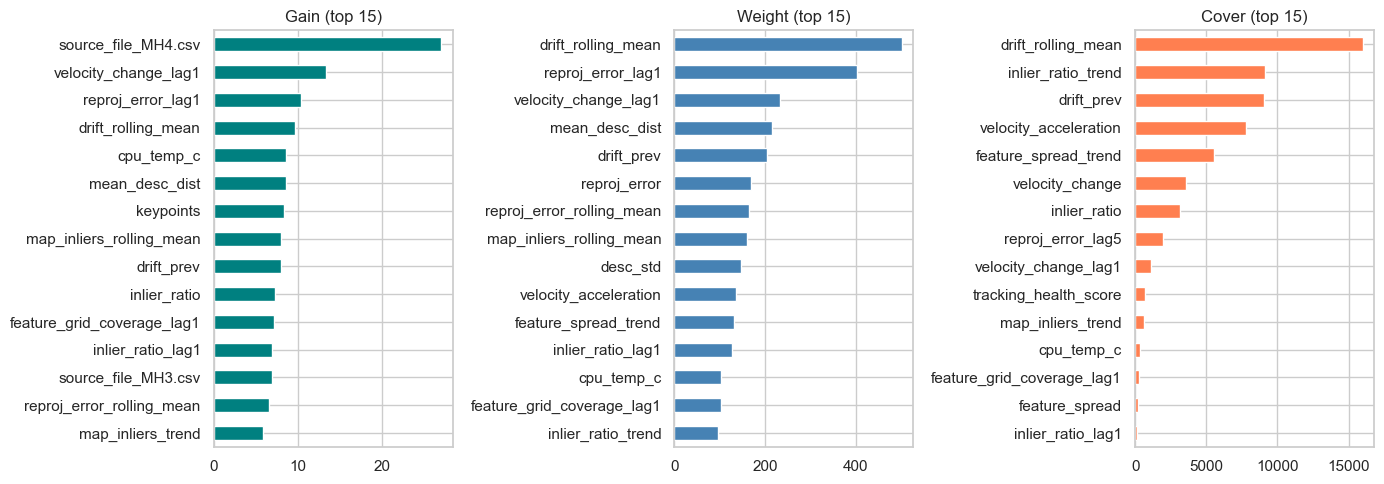

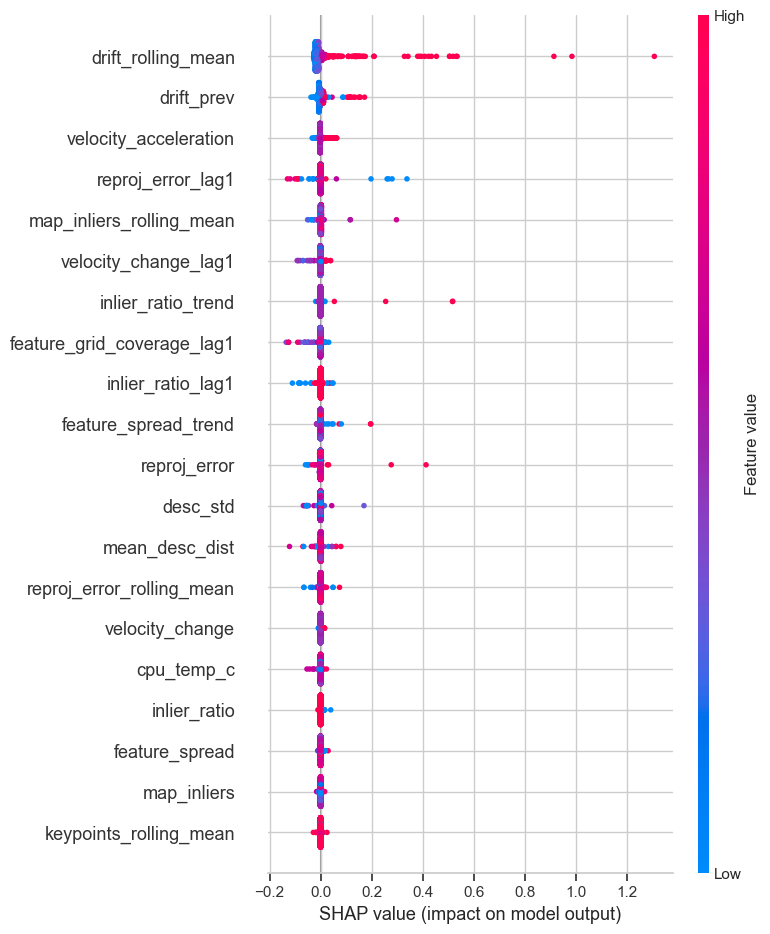

Top fitur menurut mean |SHAP|:
  drift_rolling_mean: 0.023853
  drift_prev: 0.007573
  velocity_acceleration: 0.003790
  reproj_error_lag1: 0.002202
  map_inliers_rolling_mean: 0.001986
  velocity_change_lag1: 0.001796
  inlier_ratio_trend: 0.001484
  feature_grid_coverage_lag1: 0.001458
  inlier_ratio_lag1: 0.001319
  feature_spread_trend: 0.001298


In [11]:
# Gain / Weight / Cover + SHAP: selalu model tabular dengan hiperparameter optimal
model_shap = tuned_xgb
X_train_shap = X_train_s
names_plot = list(feature_names)

def _xgb_for_importance(m):
    if isinstance(m, VotingRegressor):
        return m.named_estimators_["m1"]
    return m

booster = None
sub_m = _xgb_for_importance(model_shap)
if hasattr(sub_m, "get_booster"):
    booster = sub_m.get_booster()

if booster is not None:
    imp_gain = booster.get_score(importance_type="gain")
    imp_weight = booster.get_score(importance_type="weight")
    imp_cover = booster.get_score(importance_type="cover")

    def score_series(score_dict, names):
        arr = np.zeros(len(names))
        for i, _ in enumerate(names):
            k = f"f{i}"
            if k in score_dict:
                arr[i] = score_dict[k]
        return pd.Series(arr, index=names).sort_values(ascending=False)

    sg = score_series(imp_gain, names_plot)
    sw = score_series(imp_weight, names_plot)
    scv = score_series(imp_cover, names_plot)
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    sg.head(15).iloc[::-1].plot(kind="barh", ax=axes[0], color="teal")
    axes[0].set_title("Gain (top 15)")
    sw.head(15).iloc[::-1].plot(kind="barh", ax=axes[1], color="steelblue")
    axes[1].set_title("Weight (top 15)")
    scv.head(15).iloc[::-1].plot(kind="barh", ax=axes[2], color="coral")
    axes[2].set_title("Cover (top 15)")
    plt.tight_layout()
    plt.show()

# SHAP (subsample untuk kecepatan)
n_shap = min(1500, X_train_shap.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(X_train_shap.shape[0], size=n_shap, replace=False)
X_shap = X_train_shap[idx]

explainer = shap.TreeExplainer(_xgb_for_importance(model_shap))
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, feature_names=names_plot, show=True, max_display=20)

print("Top fitur menurut mean |SHAP|:")
shap_imp = np.abs(shap_values).mean(axis=0)
order = np.argsort(-shap_imp)
for j in order[:10]:
    print(f"  {names_plot[j]}: {shap_imp[j]:.6f}")

## Learning curve (model utama tabular)

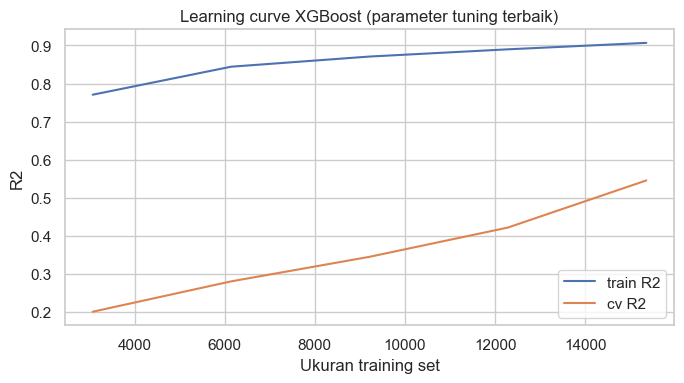

In [12]:
lc_est = make_xgb(best_params)
train_sizes, train_scores, valid_scores = learning_curve(
    lc_est,
    X_train_s,
    y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=N_JOBS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)
plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_mean, label="train R2")
plt.plot(train_sizes, valid_mean, label="cv R2")
plt.xlabel("Ukuran training set")
plt.ylabel("R2")
plt.title("Learning curve XGBoost (parameter tuning terbaik)")
plt.legend()
plt.tight_layout()
plt.show()

---

# MODEL 1 — Latent LSTM + XGBoost

**Latent:** vektor berdimensi **sama** dengan jumlah fitur asli (`n_features`), tanpa kompresi dimensi.

**Split evaluasi:** jendela temporal (train awal, test akhir), urutan dari `__row_order__` (bukan timestamp/frame). Setelah data jendela disiapkan, notebook membandingkan dengan **XGBoost tabular** pada **fitur timestep terakhir** jendela yang sama (tanpa encoder), agar metrik pada domain temporal sejajar.

In [ ]:
# Siapkan urutan temporal (tanpa timestamp/frame: urutan baris asli CSV)
df_seq = df_raw.sort_values("__row_order__").reset_index(drop=True)
X_seq_df = df_seq.drop(columns=[TARGET_COL] + present_drop, errors="ignore").select_dtypes(
    include=[np.number]
).copy()
if "__row_order__" in X_seq_df.columns:
    X_seq_df = X_seq_df.drop(columns=["__row_order__"])
X_seq_df = X_seq_df.reindex(columns=feature_names)
X_seq_df = X_seq_df.fillna(0.0)
X_seq = X_seq_df.values.astype(np.float32)
y_seq = df_seq[TARGET_COL].astype(float).values.astype(np.float32)
n_features = X_seq.shape[1]

# Skala sama dengan model tabular
X_seq_s = scaler.transform(X_seq).astype(np.float32)

def build_windows(X, y, seq_len: int):
    Xw, yw = [], []
    for i in range(seq_len - 1, len(X)):
        Xw.append(X[i - seq_len + 1 : i + 1])
        yw.append(y[i])
    return np.stack(Xw, axis=0), np.array(yw, dtype=np.float32)

X_win, y_win = build_windows(X_seq_s, y_seq, SEQ_LEN)
# Split temporal: train = awal urutan, test = akhir (mengurangi data leakage waktu)
split_point = int(len(X_win) * (1 - TEST_SIZE))
idx_train = np.arange(0, split_point)
idx_test = np.arange(split_point, len(X_win))
Xw_train, Xw_test = X_win[idx_train], X_win[idx_test]
yw_train, yw_test = y_win[idx_train], y_win[idx_test]

# Perbandingan adil: tuned XGBoost tabular pada frame terakhir jendela (split temporal sama)
pred_tab_tr_temp = tuned_xgb.predict(Xw_train[:, -1, :])
pred_tab_te_temp = tuned_xgb.predict(Xw_test[:, -1, :])
m_tab_temp = {}
m_tab_temp.update(metrics_dict(yw_train, pred_tab_tr_temp, "train"))
m_tab_temp.update(metrics_dict(yw_test, pred_tab_te_temp, "test"))
print("\n=== Tuned XGBoost (frame terakhir jendela, split temporal sama) ===")
print_metrics("Tuned XGBoost temporal last-frame", m_tab_temp)

class LSTMEncoder(nn.Module):
    def __init__(self, n_feats: int, hidden: int = 128, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_feats,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden, n_feats)  # latent dim = n_feats (tanpa kompresi dimensi keluaran)

    def forward(self, x):
        # x: (B, T, F)
        out, (h_n, _) = self.lstm(x)
        last_h = h_n[-1]
        latent = self.fc(last_h)
        return latent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_encoder(encoder, epochs=25, lr=1e-3, batch_size=256):
    encoder = encoder.to(device)
    opt = torch.optim.Adam(encoder.parameters(), lr=lr)
    ds = TensorDataset(torch.from_numpy(Xw_train), torch.from_numpy(Xw_train[:, -1, :]))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
    loss_fn = nn.MSELoss()
    for ep in range(epochs):
        encoder.train()
        tot = 0.0
        for xb, target_last in dl:
            xb = xb.to(device)
            target_last = target_last.to(device)
            opt.zero_grad()
            lat = encoder(xb)
            loss = loss_fn(lat, target_last)
            loss.backward()
            opt.step()
            tot += loss.item() * xb.size(0)
        if (ep + 1) % 5 == 0:
            print(f"LSTM encoder epoch {ep+1}: MSE={tot/len(ds):.6f}")

enc_lstm = LSTMEncoder(n_feats=n_features, hidden=160, num_layers=2, dropout=0.1)
train_encoder(enc_lstm, epochs=30, lr=1e-3, batch_size=256)

@torch.no_grad()
def encode_windows(encoder, Xw):
    encoder.eval()
    out = []
    bs = 512
    Xt = torch.from_numpy(Xw).to(device)
    for i in range(0, len(Xt), bs):
        chunk = Xt[i : i + bs]
        out.append(encoder(chunk).cpu().numpy())
    return np.vstack(out)

Z_train_lstm = encode_windows(enc_lstm, Xw_train)
Z_test_lstm = encode_windows(enc_lstm, Xw_test)
assert Z_train_lstm.shape[1] == n_features

def cv_latent_xgb(Z, y, params, n_splits=3):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    sc = []
    for tr, va in kf.split(Z):
        m = make_xgb(params)
        m.fit(Z[tr], y[tr])
        sc.append(r2_score(y[va], m.predict(Z[va])))
    return float(np.mean(sc))

def lstm_xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 150, 700, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.25, log=True),
        subsample=trial.suggest_float("subsample", 0.65, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.65, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 4.0),
        min_child_weight=trial.suggest_float("min_child_weight", 1.0, 9.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 80.0, log=True),
    )
    return cv_latent_xgb(Z_train_lstm, yw_train, params)

study_lstm = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE + 3))
study_lstm.optimize(lstm_xgb_objective, n_trials=28, show_progress_bar=False)
print("Best CV R2 (latent LSTM + XGB search):", study_lstm.best_value)

xgb_lstm = make_xgb(study_lstm.best_params)
xgb_lstm.fit(Z_train_lstm, yw_train)
pred_lstm_tr = xgb_lstm.predict(Z_train_lstm)
pred_lstm_te = xgb_lstm.predict(Z_test_lstm)
m_lstm = {}
m_lstm.update(metrics_dict(yw_train, pred_lstm_tr, "train"))
m_lstm.update(metrics_dict(yw_test, pred_lstm_te, "test"))
print_metrics("LSTM latent + XGBoost", m_lstm)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(yw_test, pred_lstm_te, alpha=0.25, s=8)
ax.plot([yw_test.min(), yw_test.max()], [yw_test.min(), yw_test.max()], "r--", lw=1)
ax.set_title("LSTM latent + XGB: Prediksi vs Aktual (test)")
plt.tight_layout(); plt.show()

# SHAP untuk XGBoost pada latent
n_shap2 = min(1200, Z_train_lstm.shape[0])
idx2 = np.random.RandomState(RANDOM_STATE).choice(Z_train_lstm.shape[0], n_shap2, replace=False)
expl2 = shap.TreeExplainer(xgb_lstm)
sv2 = expl2.shap_values(Z_train_lstm[idx2])
seq_feature_names = list(X_seq_df.columns)
latent_names = [f"latent_{seq_feature_names[j]}" for j in range(n_features)]
shap.summary_plot(sv2, Z_train_lstm[idx2], feature_names=latent_names, show=True, max_display=15)

top = np.argsort(-np.abs(sv2).mean(axis=0))[:3]
for j in top:
    shap.dependence_plot(j, sv2, Z_train_lstm[idx2], feature_names=latent_names, show=True)

print("Interpretasi laten dominan (korespondensi 1-1 dengan fitur asli):")
for j in top:
    print(f"  {latent_names[j]} ↔ fitur asli `{seq_feature_names[j]}`")


=== Tuned XGBoost (frame terakhir jendela, split temporal sama) ===
Tuned XGBoost temporal last-frame
  test_mae: 0.019406
  test_r2: 0.906648
  test_rmse: 0.070323
  train_mae: 0.014415
  train_r2: 0.874562
  train_rmse: 0.069577
LSTM encoder epoch 5: MSE=0.120017


---

# MODEL 2 — Latent PatchTST + XGBoost

Encoder ringan berbasis **patch + Transformer**; proyeksi akhir ke dimensi **n_features** (tanpa kompresi kolom).

In [ ]:
class PatchTSTEncoder(nn.Module):
    """Patching pada dimensi waktu, setiap patch memuat semua fitur (flatten patch_len * n_feats -> d_model)."""
    def __init__(
        self,
        n_feats: int,
        seq_len: int,
        patch_len: int = PATCH_LEN,
        stride: int = PATCH_STRIDE,
        d_model: int = 96,
        nhead: int = 4,
        num_layers: int = 2,
        dim_ff: int = 192,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.n_feats = n_feats
        self.patch_len = patch_len
        self.stride = stride
        patches = (seq_len - patch_len) // stride + 1
        if patches < 1:
            raise ValueError("SEQ_LEN terlalu kecil untuk patch")
        self.num_patches = patches
        patch_dim = patch_len * n_feats
        self.patch_embed = nn.Linear(patch_dim, d_model)
        self.pos = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, n_feats)

    def forward(self, x):
        # x: B, T, F
        B, T, F = x.shape
        p, s = self.patch_len, self.stride
        patches = []
        for i in range(0, T - p + 1, s):
            patches.append(x[:, i : i + p, :].reshape(B, -1))
        x_patch = torch.stack(patches, dim=1)  # B, num_patches, p*F
        h = self.patch_embed(x_patch) + self.pos
        h = self.encoder(h)
        h_mean = h.mean(dim=1)
        latent = self.fc(h_mean)
        return latent

enc_ptst = PatchTSTEncoder(
    n_feats=n_features,
    seq_len=SEQ_LEN,
    patch_len=PATCH_LEN,
    stride=PATCH_STRIDE,
    d_model=112,
    nhead=4,
    num_layers=2,
    dim_ff=224,
    dropout=0.1,
)

def train_encoder_ptst(encoder, epochs=30, lr=1e-3, batch_size=256):
    encoder = encoder.to(device)
    opt = torch.optim.AdamW(encoder.parameters(), lr=lr, weight_decay=1e-4)
    ds = TensorDataset(torch.from_numpy(Xw_train), torch.from_numpy(Xw_train[:, -1, :]))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)
    loss_fn = nn.MSELoss()
    for ep in range(epochs):
        encoder.train()
        tot = 0.0
        for xb, target_last in dl:
            xb = xb.to(device)
            target_last = target_last.to(device)
            opt.zero_grad()
            lat = encoder(xb)
            loss = loss_fn(lat, target_last)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
            opt.step()
            tot += loss.item() * xb.size(0)
        if (ep + 1) % 5 == 0:
            print(f"PatchTST encoder epoch {ep+1}: MSE={tot/len(ds):.6f}")

train_encoder_ptst(enc_ptst, epochs=35, lr=8e-4, batch_size=256)

Z_train_pt = encode_windows(enc_ptst, Xw_train)
Z_test_pt = encode_windows(enc_ptst, Xw_test)
assert Z_train_pt.shape[1] == n_features

# tuning ringkas dengan Optuna pada XGBoost latent PatchTST
def ptst_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 150, 700, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.25, log=True),
        subsample=trial.suggest_float("subsample", 0.65, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.65, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 4.0),
        min_child_weight=trial.suggest_float("min_child_weight", 1.0, 9.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 80.0, log=True),
    )
    return cv_latent_xgb(Z_train_pt, yw_train, params)

study_pt = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))
study_pt.optimize(ptst_objective, n_trials=28, show_progress_bar=False)
print("Best CV R2 (latent PatchTST + XGB search):", study_pt.best_value)

xgb_ptst = make_xgb(study_pt.best_params)
xgb_ptst.fit(Z_train_pt, yw_train)
pred_pt_tr = xgb_ptst.predict(Z_train_pt)
pred_pt_te = xgb_ptst.predict(Z_test_pt)
m_pt = {}
m_pt.update(metrics_dict(yw_train, pred_pt_tr, "train"))
m_pt.update(metrics_dict(yw_test, pred_pt_te, "test"))
print_metrics("PatchTST latent + XGBoost", m_pt)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(yw_test, pred_pt_te, alpha=0.25, s=8)
ax.plot([yw_test.min(), yw_test.max()], [yw_test.min(), yw_test.max()], "r--", lw=1)
ax.set_title("PatchTST latent + XGB: Prediksi vs Aktual (test)")
plt.tight_layout(); plt.show()

idx3 = np.random.RandomState(RANDOM_STATE + 2).choice(Z_train_pt.shape[0], min(1200, Z_train_pt.shape[0]), replace=False)
expl3 = shap.TreeExplainer(xgb_ptst)
sv3 = expl3.shap_values(Z_train_pt[idx3])
shap.summary_plot(sv3, Z_train_pt[idx3], feature_names=latent_names, show=True, max_display=15)

rank_idx = np.argsort(-np.abs(sv3).mean(axis=0))
print("Ranking latent (mean |SHAP|):")
for r, j in enumerate(rank_idx[:15], 1):
    print(f"  {r:2d}. {latent_names[j]} -> asli `{seq_feature_names[j]}` | {np.abs(sv3).mean(axis=0)[j]:.6f}")

---

## Ringkasan perbandingan & kesimpulan

In [ ]:
summary_rows = [
    {"model": "Baseline XGBoost (scaled tabular, split acak)", **m_base},
    {"model": "Tuned XGBoost (tabular, split acak)", **m_tuned},
    {"model": "Tuned XGBoost (frame terakhir, split temporal)", **m_tab_temp},
    {"model": "LSTM latent + XGBoost (split temporal)", **m_lstm},
    {"model": "PatchTST latent + XGBoost (split temporal)", **m_pt},
]
sum_tbl = pd.DataFrame(summary_rows)
display(sum_tbl.sort_values("test_r2", ascending=False))

best_final = sum_tbl.sort_values("test_r2", ascending=False).iloc[0]
print("\nModel terbaik (test R2):", best_final["model"])
print("Metrik test:", {k: best_final[k] for k in ("test_r2", "test_rmse", "test_mae") if k in best_final})

print(
    "\nInterpretabilitas: model tabular XGBoost pada fitur asli paling mudah dihubungkan dengan domain. "
    "Latent LSTM/PatchTST diproyeksikan ke vektor berdimensi sama dengan fitur asli; indeks j pada laten "
    "dapat dibaca berdampingan dengan nama kolom asli `seq_feature_names[j]` pada SHAP."
)